# Final Notebook - Hybrid Lorentz-ParT MAE (GSoC 2026)

This notebook consolidates analysis and implementation upgrades for:
- Event classification with masked transformer autoencoders
- 100,000 events total with 80/10/10 split
- Improvements over baseline hybrid Lorentz + ParT architecture

## What is included
1. Audit of current project notebooks and architecture status
2. Practical, research-backed improvements for speed and accuracy
3. A strict ablation plan and report template for GSoC selection
4. Drop-in code blocks to upgrade your existing training notebook

## Important note
I could not find the two PDF research papers in the current workspace. Add them to this project folder and I will integrate paper-specific equations/choices directly into the code.

## A) Project Audit (from your current notebooks)

### Strong parts already present in your latest notebook (`v8_Hybrid_Lorentz_ParT_MAE_JetClass_GSoC2026.ipynb`)
- Hybrid ParT + Lorentz stream fusion
- Masked autoencoder pretraining pipeline
- JEPA-style latent prediction switch
- Attention gating in both ParT and Lorentz blocks
- Auxiliary mass regression head
- Multi-pool event representation
- Ablation section (scratch vs pretrain)

### Gaps to improve for selection-level quality
- Speed path is not yet explicit (compile/SDPA/checkpointing toggles)
- JEPA can be further stabilized with variance-covariance regularization
- Need cleaner, fixed ablation matrix with confidence intervals
- Need reproducible reporting format (accuracy, macro-AUC, bg-rejection@50% signal eff)
- Need explicit "100k split protocol" and fixed seeds across all runs

In [1]:
# B) Drop-in config patch for your main training notebook
# Copy this block into your working notebook's Config class and setup section.

from dataclasses import dataclass
from typing import Tuple, Optional

@dataclass
class UpgradeConfig:
    # Repro protocol
    SAMPLE_SIZE: int = 100_000
    TRAIN_FRAC: float = 0.80
    VAL_FRAC: float = 0.10
    TEST_FRAC: float = 0.10
    SEED: int = 42

    # Speed toggles
    USE_TORCH_COMPILE: bool = True
    TORCH_COMPILE_MODE: str = "reduce-overhead"   # or "max-autotune"
    USE_GRAD_CHECKPOINT: bool = True
    USE_CHANNELS_LAST: bool = False  # mostly useful for CNN workloads; keep False here
    ENABLE_TF32: bool = True

    # Attention backend hints
    USE_SDPA_HINTS: bool = True

    # JEPA stability add-on
    USE_VICREG_ON_JEPA: bool = True
    VICREG_VAR_W: float = 10.0
    VICREG_COV_W: float = 1.0
    VICREG_INV_W: float = 25.0

    # Loss improvements
    LABEL_SMOOTHING: float = 0.10
    GRAD_CLIP_NORM: float = 1.0

    # Ablation reproducibility
    NUM_SEEDS_PER_SETTING: int = 3
    ABLATION_SEEDS: Tuple[int, ...] = (42, 52, 62)

ucfg = UpgradeConfig()
print("UpgradeConfig ready")

# Runtime knobs
import torch
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = bool(ucfg.ENABLE_TF32)
    torch.backends.cudnn.allow_tf32 = bool(ucfg.ENABLE_TF32)
print("TF32:", torch.backends.cuda.matmul.allow_tf32 if torch.cuda.is_available() else "N/A")

UpgradeConfig ready
TF32: True


In [2]:
# C) JEPA + VICReg regularization (drop-in)
# Integrate this into your pretraining loss path when USE_JEPA_PRETRAIN=True.

import torch
import torch.nn.functional as F


def _variance_term(z, eps=1e-4):
    # Encourage non-collapsed dimensions
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(F.relu(1.0 - std))


def _covariance_term(z):
    # Penalize redundant feature dimensions
    z = z - z.mean(dim=0, keepdim=True)
    n, d = z.shape
    cov = (z.T @ z) / max(n - 1, 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return (off_diag.pow(2).sum() / d)


def vicreg_loss(pred, target, inv_w=25.0, var_w=10.0, cov_w=1.0):
    # pred, target: [num_tokens, d]
    inv = F.smooth_l1_loss(pred, target)
    var = _variance_term(pred) + _variance_term(target)
    cov = _covariance_term(pred) + _covariance_term(target)
    return inv_w * inv + var_w * var + cov_w * cov, {
        "inv": float(inv.detach().cpu()),
        "var": float(var.detach().cpu()),
        "cov": float(cov.detach().cpu()),
    }


def jepa_with_optional_vicreg(pred_latent_masked, target_latent_full, token_mask, cfg):
    # token_mask: True at positions included in JEPA objective
    p = pred_latent_masked[token_mask]
    t = target_latent_full[token_mask].detach()

    if p.numel() == 0:
        return pred_latent_masked.sum() * 0.0, {"inv": 0.0, "var": 0.0, "cov": 0.0}

    if getattr(cfg, "USE_VICREG_ON_JEPA", False):
        return vicreg_loss(
            p, t,
            inv_w=getattr(cfg, "VICREG_INV_W", 25.0),
            var_w=getattr(cfg, "VICREG_VAR_W", 10.0),
            cov_w=getattr(cfg, "VICREG_COV_W", 1.0),
        )

    base = F.smooth_l1_loss(p, t)
    return base, {"inv": float(base.detach().cpu()), "var": 0.0, "cov": 0.0}

In [3]:
# D) Speed patch helpers (drop-in)
# Use these with your model/optimizer creation code.

import torch
from contextlib import nullcontext


def maybe_compile_model(model, cfg):
    if getattr(cfg, "USE_TORCH_COMPILE", False) and hasattr(torch, "compile"):
        try:
            return torch.compile(model, mode=getattr(cfg, "TORCH_COMPILE_MODE", "reduce-overhead"))
        except Exception as ex:
            print(f"[WARN] torch.compile unavailable/failing, fallback eager: {ex}")
            return model
    return model


def amp_context(device):
    if str(device).startswith("cuda"):
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def apply_grad_checkpoint_if_available(module, cfg):
    # Placeholder hook for wrapping large blocks with checkpointing.
    # In your model forward, call torch.utils.checkpoint.checkpoint(block, ...)
    return bool(getattr(cfg, "USE_GRAD_CHECKPOINT", False))


print("Speed helpers loaded")

Speed helpers loaded


In [4]:
# E) Strict ablation protocol (selection-focused)

import pandas as pd

ABLATIONS = [
    {"name": "Baseline", "use_jepa": False, "use_gate": False, "use_mass": False},
    {"name": "+MAE", "use_jepa": False, "use_gate": False, "use_mass": False},
    {"name": "+MAE+Gate", "use_jepa": False, "use_gate": True, "use_mass": False},
    {"name": "+JEPA", "use_jepa": True, "use_gate": True, "use_mass": False},
    {"name": "+JEPA+VICReg", "use_jepa": True, "use_gate": True, "use_mass": False},
    {"name": "+JEPA+VICReg+Mass", "use_jepa": True, "use_gate": True, "use_mass": True},
]

METRIC_COLUMNS = [
    "setting", "seed", "val_auc", "test_acc", "test_macro_auc", "bkg_rej_at_50",
    "train_time_min", "gpu_mem_gb",
]

results = []

# Fill results inside your training loop, one entry per (setting, seed)
# results.append({...})

report_df = pd.DataFrame(results, columns=METRIC_COLUMNS)
if len(report_df) == 0:
    print("Run experiments, then populate `results` and rerun this cell.")
else:
    agg = report_df.groupby("setting").agg({
        "val_auc": ["mean", "std"],
        "test_acc": ["mean", "std"],
        "test_macro_auc": ["mean", "std"],
        "bkg_rej_at_50": ["mean", "std"],
        "train_time_min": ["mean"],
        "gpu_mem_gb": ["mean"],
    })
    display(report_df)
    display(agg)

Run experiments, then populate `results` and rerun this cell.


## Next step for your actual implementation notebook

Share your active notebook (the one you want to submit), and I will directly patch it to include:
- JEPA + VICReg objective in pretraining path
- optional `torch.compile` and safe fallback
- gradient checkpointing in heavy blocks
- strict 100k split reproducibility controls
- a final ablation section with mean ± std over multiple seeds

Once you send it, I will edit it line-by-line for a submission-grade final version.

## Full Project Implementation

This section is a complete, runnable pipeline:
1. Setup and configuration
2. JetClass loading (ROOT if available, synthetic fallback)
3. Hybrid Lorentz + ParT model
4. MAE or JEPA pretraining
5. Supervised finetuning (classification + optional mass regression)
6. Evaluation and ablation utilities

In [5]:
# 1) Setup

import os
import math
import time
import random
import copy
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Optional, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

try:
    import uproot
    import awkward as ak
    HAS_ROOT = True
except Exception:
    HAS_ROOT = False


@dataclass
class Config:
    # Data
    DATA_ROOT: str = '../datasets/JetClass'
    # Task 2a hard requirement: use exactly 100,000 events with 80/10/10 split.
    SAMPLE_SIZE: int = 100_000
    TRAIN_FRAC: float = 0.8
    VAL_FRAC: float = 0.1
    TEST_FRAC: float = 0.1
    STRICT_DATASET_ONLY: bool = False  # FIX: allow synthetic fallback

    MAX_PARTICLES: int = 50
    NUM_CLASSES: int = 10

    # Added m2 as a physics-informed per-particle invariant feature.
    PER_PARTICLE_FEATURES: Tuple[str, ...] = (
        'px','py','pz','E','pt','eta','phi','m2','charge',
        'isChargedHadron','isNeutralHadron','isPhoton','isElectron','isMuon',
        'd0val','d0err','dzval','dzerr','valid_mask'
    )

    # Model
    EMBED_DIM: int = 128
    NUM_HEADS: int = 8
    NUM_PART_BLOCKS: int = 4
    NUM_LOR_BLOCKS: int = 3
    DROPOUT: float = 0.1
    MLP_RATIO: float = 4.0

    # Physics + interaction toggles for ablations.
    USE_PHYSICS_FEATURES: bool = True
    USE_PHYSICS_PAIR_BIAS: bool = True   # ParT Eq.(3)/(4)-style pair bias
    USE_INTERACTION_LEARNING: bool = True
    USE_ATTN_TOKEN_GATING: bool = True
    USE_BEAM_TOKENS: bool = True         # L-GATr-style symmetry-breaking inputs

    # Pretraining
    PRETRAIN_EPOCHS: int = 12
    MASK_RATIO: float = 0.5
    USE_BIASED_MASK: bool = True
    PRETRAIN_MASK_MODE_TRAIN: str = 'topk'   # ['biased', 'topk', 'first', 'random']
    PRETRAIN_MASK_MODE_EVAL: str = 'first'
    USE_JEPA_PRETRAIN: bool = True
    USE_TRUE_JEPA: bool = True
    JEPA_EMA_MOMENTUM: float = 0.99
    USE_VICREG_ON_JEPA: bool = True
    JEPA_WEIGHT: float = 1.0
    VICREG_INV_W: float = 25.0
    VICREG_VAR_W: float = 10.0
    VICREG_COV_W: float = 1.0
    PRETRAIN_LR: float = 2e-4

    # Finetune
    FINETUNE_EPOCHS: int = 20
    FINETUNE_LR: float = 1e-4
    LABEL_SMOOTHING: float = 0.15
    USE_AUX_MASS: bool = True
    AUX_MASS_WEIGHT: float = 0.3
    MASS_NORM_SCALE: float = 100.0

    # Pooling
    USE_ATTN_POOLING: bool = True

    # Infra
    BATCH_SIZE: int = 128
    NUM_WORKERS: int = 0
    WEIGHT_DECAY: float = 0.01
    GRAD_CLIP_NORM: float = 1.0
    USE_AMP: bool = True
    USE_TORCH_COMPILE: bool = False  # FIX: set True only if triton installed
    SEED: int = 42

cfg = Config()

# Requested ablation aliases (lowercase) kept in sync with existing uppercase flags.
cfg.use_jepa = cfg.USE_JEPA_PRETRAIN
cfg.use_interaction = cfg.USE_INTERACTION_LEARNING
cfg.use_gating = cfg.USE_ATTN_TOKEN_GATING
cfg.use_physics = cfg.USE_PHYSICS_FEATURES


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(cfg.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = cfg.USE_AMP and device.type == 'cuda'
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print('Device:', device, '| AMP:', amp_enabled, '| ROOT:', HAS_ROOT)

Device: cuda | AMP: True | ROOT: True


In [6]:
# 2) Data loading

BRANCH_CANDIDATES = {
    'px':['part_px','px'],'py':['part_py','py'],'pz':['part_pz','pz'],
    'E':['part_energy','part_e','energy','E'],
    'pt':['part_pt','pt'],'eta':['part_eta','eta'],'phi':['part_phi','phi'],
    'charge':['part_charge','charge'],
    'isChargedHadron':['part_isChargedHadron','isChargedHadron'],
    'isNeutralHadron':['part_isNeutralHadron','isNeutralHadron'],
    'isPhoton':['part_isPhoton','isPhoton'],'isElectron':['part_isElectron','isElectron'],'isMuon':['part_isMuon','isMuon'],
    'd0val':['part_d0val','d0val'],'d0err':['part_d0err','d0err'],'dzval':['part_dzval','dzval'],'dzerr':['part_dzerr','dzerr']
}


def resolve_branches(available, candidates):
    lower = {a.lower(): a for a in available}
    out = {}
    for k, opts in candidates.items():
        out[k] = next((o for o in opts if o in available or o.lower() in lower), None)
    return out


def infer_class_name(path_str: str) -> str:
    return Path(path_str).stem.split('_')[0]


def discover_root_files(root_dir: str) -> List[str]:
    p = Path(root_dir)
    if not p.exists():
        return []
    return [str(x) for x in p.rglob('*.root')]


def safe_eta(px, py, pz, eps=1e-8):
    p = np.sqrt(px**2 + py**2 + pz**2 + eps)
    v = np.clip(pz / (p + eps), -1 + 1e-6, 1 - 1e-6)
    return np.arctanh(v)


def _zscore_valid(samples, feat_names, feat_key, eps=1e-6):
    """Normalize physics channels on train split only to avoid leakage."""
    if feat_key not in feat_names:
        return (0.0, 1.0)

    idx = feat_names.index(feat_key)
    vals = []
    for x, mask, *_ in samples:
        vm = mask > 0.5
        if vm.any():
            vals.append(x[vm, idx])

    if len(vals) == 0:
        return (0.0, 1.0)

    arr = np.concatenate(vals)
    mean = float(arr.mean())
    std = float(arr.std()) + eps
    return mean, std


def _apply_zscore(samples, feat_names, feat_key, mean, std):
    if feat_key not in feat_names:
        return samples
    idx = feat_names.index(feat_key)
    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            x2[vm, idx] = (x2[vm, idx] - mean) / std
        out.append((x2, mask, p4, y, m))
    return out


def _zero_feature_channels(samples, feat_names, feature_keys):
    idxs = [feat_names.index(fk) for fk in feature_keys if fk in feat_names]
    if len(idxs) == 0:
        return samples
    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            x2[np.ix_(vm, idxs)] = 0.0
        out.append((x2, mask, p4, y, m))
    return out


def read_root_file(fp: str, max_events: Optional[int] = None) -> List[Dict[str, np.ndarray]]:
    events = []
    with uproot.open(fp) as f:
        tname = next((k for k in ['tree', 'events', 'Events', 'JetTree'] if k in f), None)
        if tname is None:
            tname = next((k for k in f.keys() if hasattr(f[k], 'arrays')), None)
        if tname is None:
            raise RuntimeError('No readable tree found')
        tree = f[tname]

        av = [str(x) for x in tree.keys()]
        bm = resolve_branches(av, BRANCH_CANDIDATES)
        keys = [v for v in bm.values() if v is not None]
        if len(keys) == 0:
            raise RuntimeError('No matching branches found')
        arrs = tree.arrays(keys, library='ak', entry_stop=max_events)

        n = len(arrs[keys[0]])
        Fdim = len(cfg.PER_PARTICLE_FEATURES)
        N = cfg.MAX_PARTICLES

        for i in range(n):
            def g(name):
                b = bm.get(name)
                if b is None:
                    return None
                try:
                    obj = arrs[b][i]
                    raw = ak.to_numpy(obj) if hasattr(obj, '__len__') else np.array([obj])
                    return np.nan_to_num(raw.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
                except Exception:
                    return None

            px = g('px'); py = g('py'); pz = g('pz'); E = g('E')
            if px is None or py is None or pz is None:
                continue

            pt = g('pt')
            eta = g('eta')
            phi = g('phi')
            if pt is None:
                pt = np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32)
            if eta is None:
                eta = safe_eta(px, py, pz).astype(np.float32)
            if phi is None:
                phi = np.arctan2(py, px).astype(np.float32)
            if E is None:
                E = (pt * np.cosh(np.clip(eta, -5, 5))).astype(np.float32)

            p2 = (px**2 + py**2 + pz**2).astype(np.float32)
            m2 = (E**2 - p2).astype(np.float32)

            npar = len(px)
            if npar == 0:
                continue

            x = np.zeros((N, Fdim), dtype=np.float32)
            p4 = np.zeros((N, 4), dtype=np.float32)
            mask = np.zeros((N,), dtype=np.float32)

            keep = min(npar, N)
            sl = slice(0, keep)

            base = {
                'px': px[:keep], 'py': py[:keep], 'pz': pz[:keep], 'E': E[:keep],
                'pt': pt[:keep], 'eta': eta[:keep], 'phi': phi[:keep], 'm2': m2[:keep],
                'charge': np.zeros(keep, np.float32),
                'isChargedHadron': np.zeros(keep, np.float32),
                'isNeutralHadron': np.zeros(keep, np.float32),
                'isPhoton': np.zeros(keep, np.float32),
                'isElectron': np.zeros(keep, np.float32),
                'isMuon': np.zeros(keep, np.float32),
                'd0val': np.zeros(keep, np.float32),
                'd0err': np.zeros(keep, np.float32),
                'dzval': np.zeros(keep, np.float32),
                'dzerr': np.zeros(keep, np.float32),
                'valid_mask': np.ones(keep, np.float32),
            }

            for feat in ['charge','isChargedHadron','isNeutralHadron','isPhoton','isElectron','isMuon','d0val','d0err','dzval','dzerr']:
                arr = g(feat)
                if arr is not None and len(arr) >= keep:
                    base[feat] = arr[:keep].astype(np.float32)

            for j, feat in enumerate(cfg.PER_PARTICLE_FEATURES):
                x[sl, j] = base[feat]

            p4[sl, 0] = base['E']
            p4[sl, 1] = base['px']
            p4[sl, 2] = base['py']
            p4[sl, 3] = base['pz']
            mask[sl] = 1.0
            events.append({'x': x, 'p4': p4, 'mask': mask})

    return events


def make_synthetic(n=100_000, seed=42):
    rng = np.random.default_rng(seed)
    N, Fdim = cfg.MAX_PARTICLES, len(cfg.PER_PARTICLE_FEATURES)
    pt_scales = [20, 30, 15, 25, 18, 40, 35, 22, 28, 24]
    samples = []

    for cls in range(cfg.NUM_CLASSES):
        n_cls = n // cfg.NUM_CLASSES
        for _ in range(n_cls):
            nv = int(rng.integers(10, N + 1))
            pt = rng.exponential(pt_scales[cls % len(pt_scales)], nv).astype(np.float32)
            eta = rng.uniform(-2.5, 2.5, nv).astype(np.float32)
            phi = rng.uniform(-math.pi, math.pi, nv).astype(np.float32)
            E = (pt * np.cosh(np.clip(eta, -5, 5))).astype(np.float32)
            px = (pt * np.cos(phi)).astype(np.float32)
            py = (pt * np.sin(phi)).astype(np.float32)
            pz = (pt * np.sinh(np.clip(eta, -5, 5))).astype(np.float32)

            p2 = (px**2 + py**2 + pz**2).astype(np.float32)
            m2 = (E**2 - p2).astype(np.float32)

            order = np.argsort(-pt)
            px, py, pz, E, pt, eta, phi, m2 = [a[order] for a in [px, py, pz, E, pt, eta, phi, m2]]

            x = np.zeros((N, Fdim), dtype=np.float32)
            p4 = np.zeros((N, 4), dtype=np.float32)
            mask = np.zeros((N,), dtype=np.float32)

            keep = min(nv, N)
            vals = {
                'px': px[:keep], 'py': py[:keep], 'pz': pz[:keep], 'E': E[:keep], 'pt': pt[:keep], 'eta': eta[:keep], 'phi': phi[:keep], 'm2': m2[:keep],
                'charge': rng.integers(-1, 2, keep).astype(np.float32),
                'isChargedHadron': rng.integers(0, 2, keep).astype(np.float32),
                'isNeutralHadron': rng.integers(0, 2, keep).astype(np.float32),
                'isPhoton': rng.integers(0, 2, keep).astype(np.float32),
                'isElectron': rng.integers(0, 2, keep).astype(np.float32),
                'isMuon': rng.integers(0, 2, keep).astype(np.float32),
                'd0val': rng.normal(0, 0.1, keep).astype(np.float32),
                'd0err': rng.uniform(0.01, 0.2, keep).astype(np.float32),
                'dzval': rng.normal(0, 0.2, keep).astype(np.float32),
                'dzerr': rng.uniform(0.01, 0.2, keep).astype(np.float32),
                'valid_mask': np.ones(keep, dtype=np.float32),
            }

            for j, feat in enumerate(cfg.PER_PARTICLE_FEATURES):
                x[:keep, j] = vals[feat]
            p4[:keep, 0] = vals['E']; p4[:keep, 1] = vals['px']; p4[:keep, 2] = vals['py']; p4[:keep, 3] = vals['pz']
            mask[:keep] = 1.0

            mass2 = np.maximum((vals['E'].sum())**2 - (vals['px'].sum()**2 + vals['py'].sum()**2 + vals['pz'].sum()**2), 0.0)
            mass = float(np.sqrt(mass2))
            samples.append((x, mask, p4, cls, mass))

    random.shuffle(samples)
    return samples[:n]


class JetDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        x, mask, p4, y, m = self.samples[i]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'p4': torch.tensor(p4, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long),
            'mass': torch.tensor(m, dtype=torch.float32),
        }


def build_loaders(cfg):
    files = discover_root_files(cfg.DATA_ROOT)
    samples = []

    if files and HAS_ROOT:
        cls_names = sorted({infer_class_name(f) for f in files})
        c2i = {c: i for i, c in enumerate(cls_names)}
        cfg.NUM_CLASSES = len(cls_names)

        per_file = max(1, int(math.ceil(cfg.SAMPLE_SIZE / max(len(files), 1))))
        for fp in files:
            y = c2i[infer_class_name(fp)]
            try:
                evs = read_root_file(fp, max_events=per_file)
            except Exception as ex:
                print(f'[WARN] {Path(fp).name}: {ex}')
                continue
            for e in evs:
                E, px, py, pz = e['p4'][:,0], e['p4'][:,1], e['p4'][:,2], e['p4'][:,3]
                mass2 = np.maximum((E.sum())**2 - (px.sum()**2 + py.sum()**2 + pz.sum()**2), 0.0)
                mass = float(np.sqrt(mass2))
                samples.append((e['x'], e['mask'], e['p4'], y, mass))

        if len(samples) < cfg.SAMPLE_SIZE:
            raise RuntimeError(
                f"Only {len(samples)} events were found in DATA_ROOT={cfg.DATA_ROOT}. "
                f"Task requires exactly {cfg.SAMPLE_SIZE}."
            )
        samples = samples[:cfg.SAMPLE_SIZE]
    else:
        if cfg.STRICT_DATASET_ONLY:
            raise RuntimeError(
                "No ROOT files found (or uproot unavailable). For strict CMS Task 2a alignment, "
                "set DATA_ROOT correctly and provide JetClass files."
            )
        samples = make_synthetic(cfg.SAMPLE_SIZE, seed=cfg.SEED)

    n_total = len(samples)
    n_test = int(round(cfg.TEST_FRAC * n_total))
    n_val = int(round(cfg.VAL_FRAC * n_total))
    n_train = n_total - n_test - n_val

    y_all = [s[3] for s in samples]
    trva, te = train_test_split(samples, test_size=n_test, random_state=cfg.SEED, stratify=y_all)
    y_trva = [s[3] for s in trva]
    tr, va = train_test_split(trva, test_size=n_val, random_state=cfg.SEED, stratify=y_trva)

    assert len(tr) == n_train and len(va) == n_val and len(te) == n_test

    feat_names = list(cfg.PER_PARTICLE_FEATURES)
    if cfg.USE_PHYSICS_FEATURES:
        for fk in ['px','py','pz','E','pt','eta','m2','d0val','d0err','dzval','dzerr']:  # FIX: all kinematics
            mu, sd = _zscore_valid(tr, feat_names, fk)
            tr = _apply_zscore(tr, feat_names, fk, mu, sd)
            va = _apply_zscore(va, feat_names, fk, mu, sd)
            te = _apply_zscore(te, feat_names, fk, mu, sd)
    else:
        tr = _zero_feature_channels(tr, feat_names, ['pt', 'm2'])
        va = _zero_feature_channels(va, feat_names, ['pt', 'm2'])
        te = _zero_feature_channels(te, feat_names, ['pt', 'm2'])

    train_loader = DataLoader(JetDataset(tr), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    val_loader = DataLoader(JetDataset(va), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    test_loader = DataLoader(JetDataset(te), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)

    print(f'Train/Val/Test = {len(tr)}/{len(va)}/{len(te)} (strict 80/10/10)')
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_loaders(cfg)

Train/Val/Test = 80000/10000/10000 (strict 80/10/10)


In [7]:
# 3) Hybrid model: ParT + Lorentz + gated fusion

def _dphi(d):
    return (d + math.pi) % (2 * math.pi) - math.pi


def compute_pairwise(p4, mask, eps=1e-8):
    E, px, py, pz = p4[...,0], p4[...,1], p4[...,2], p4[...,3]
    pt = torch.sqrt(px**2 + py**2 + eps)
    eta = torch.atanh(torch.clamp(pz / (torch.sqrt(px**2 + py**2 + pz**2 + eps) + eps), -1 + 1e-6, 1 - 1e-6))
    phi = torch.atan2(py, px)

    deta = eta.unsqueeze(2) - eta.unsqueeze(1)
    dphi = _dphi(phi.unsqueeze(2) - phi.unsqueeze(1))
    delta = torch.sqrt(deta**2 + dphi**2 + eps)

    pti, ptj = pt.unsqueeze(2), pt.unsqueeze(1)
    kT = torch.minimum(pti, ptj) * delta
    z = torch.minimum(pti, ptj) / (pti + ptj + eps)

    Ei, Ej = E.unsqueeze(2), E.unsqueeze(1)
    m2 = (Ei + Ej)**2 - ((px.unsqueeze(2)+px.unsqueeze(1))**2 + (py.unsqueeze(2)+py.unsqueeze(1))**2 + (pz.unsqueeze(2)+pz.unsqueeze(1))**2)

    pair = torch.stack([
        torch.log(delta + eps),
        torch.log(kT + eps),
        torch.log(z + eps),
        torch.log(torch.clamp(m2.abs(), min=eps))
    ], dim=-1)

    pair = pair * (mask.unsqueeze(1) * mask.unsqueeze(2)).unsqueeze(-1)
    return pair


def make_mask(mask, x, ratio=0.5, mode='topk'):
    """Unified masking modes with deterministic options for controlled ablations."""
    B, N = mask.shape
    out = torch.zeros(B, N, dtype=torch.bool, device=mask.device)
    pt_idx = list(cfg.PER_PARTICLE_FEATURES).index('pt')

    for b in range(B):
        idx = torch.where(mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * ratio))

        if mode == 'first':
            picked = idx[:k]
        elif mode == 'random':
            perm = torch.randperm(len(idx), device=mask.device)
            picked = idx[perm[:k]]
        elif mode == 'biased':
            ptv = x[b, idx, pt_idx]
            w = torch.ones_like(ptv)
            topn = max(1, int(0.5 * len(idx)))
            top = torch.argsort(ptv, descending=True)[:topn]
            w[top] = 3.0
            w = w / w.sum()
            picked = idx[torch.multinomial(w, k, replacement=False)]
        else:  # 'topk'
            ptv = x[b, idx, pt_idx]
            top_local = torch.argsort(ptv, descending=True)[:k]
            picked = idx[top_local]

        out[b, picked] = True
    return out


class ParticleEmbed(nn.Module):
    def __init__(self, fin, d, drop):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(fin, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, d))
    def forward(self, x):
        return self.net(x)


class LearnedPairwiseInteraction(nn.Module):
    def __init__(self, d, heads, hidden=128):
        super().__init__()
        # pair_mlp(concat(x_i, x_j)) as required by ParT-style interaction injection.
        self.pair_mlp = nn.Sequential(
            nn.Linear(2 * d, hidden),
            nn.GELU(),
            nn.Linear(hidden, heads),
        )
        # Gate is applied on pairwise logits directly for stronger adaptive modulation.
        self.interaction_gate = nn.Sequential(
            nn.Linear(heads, heads),
            nn.Sigmoid(),
        )

    def forward(self, h, mask):
        xi = h.unsqueeze(2).expand(-1, -1, h.size(1), -1)
        xj = h.unsqueeze(1).expand(-1, h.size(1), -1, -1)
        pair = torch.cat([xi, xj], dim=-1)
        pairwise = self.pair_mlp(pair)
        pairwise = pairwise * self.interaction_gate(pairwise)
        pb = pairwise.permute(0, 3, 1, 2).contiguous()
        valid = (mask.unsqueeze(1) * mask.unsqueeze(2)).unsqueeze(1)
        return pb * valid


class PhysicsPairEncoder(nn.Module):
    def __init__(self, heads):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(4, 64), nn.GELU(), nn.Linear(64, heads))

    def forward(self, pair, mask):
        pb = self.proj(pair).permute(0, 3, 1, 2).contiguous()
        valid = (mask.unsqueeze(1) * mask.unsqueeze(2)).unsqueeze(1)
        return pb * valid


def add_symmetry_breaking_tokens(x, p4, mask):
    """Adds +z/-z beam tokens to inject detector-frame symmetry breaking when useful."""
    B, _, F = x.shape
    dev = x.device

    xb = torch.zeros(B, 2, F, device=dev, dtype=x.dtype)
    p4b = torch.zeros(B, 2, 4, device=dev, dtype=p4.dtype)
    mb = torch.ones(B, 2, device=dev, dtype=mask.dtype)

    p4b[:, 0, :] = torch.tensor([1.0, 0.0, 0.0, 1.0], device=dev, dtype=p4.dtype)
    p4b[:, 1, :] = torch.tensor([1.0, 0.0, 0.0, -1.0], device=dev, dtype=p4.dtype)

    x2 = torch.cat([x, xb], dim=1)
    p42 = torch.cat([p4, p4b], dim=1)
    m2 = torch.cat([mask, mb], dim=1)
    return x2, p42, m2


class ParTBlock(nn.Module):
    def __init__(self, d, heads, mlp_ratio=4., drop=0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d)
        self.out = nn.Linear(d, d)

        # Gating before attention and over Q/K improves token saliency usage.
        self.pre_gate = nn.Sequential(nn.Linear(d, d), nn.Sigmoid())
        # FIX 3: bounded 2*sigmoid(raw_alpha) in (0,2). Was unconstrained (grew 1.0→1.4+).
        self.raw_alpha = nn.Parameter(torch.tensor(0.0))

        self.res_gate = nn.Sequential(nn.Linear(d, d // 2), nn.GELU(), nn.Linear(d // 2, 1))
        self.gate_mlp = nn.Sequential(nn.Linear(d, d // 2), nn.GELU(), nn.Linear(d // 2, d))

        self.n2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, int(d*mlp_ratio)), nn.GELU(), nn.Dropout(drop), nn.Linear(int(d*mlp_ratio), d))
        self.drop = nn.Dropout(drop)

    def forward(self, x, mask, pair_bias, use_token_gating=True):
        B, N, D = x.shape
        xn = self.n1(x)

        if use_token_gating:
            gate = self.pre_gate(xn)
            xn = xn * gate
        else:
            gate = None

        qkv = self.qkv(xn).view(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # FIX 4a: gate applied to xn only; NOT re-applied to Q/K (was effective g^2).

        alpha = 2.0 * torch.sigmoid(self.raw_alpha)  # bounded (0,2)
        attn = (q @ k.transpose(-1, -2)) * self.scale + alpha * pair_bias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        attn = attn.masked_fill(~km, torch.finfo(attn.dtype).min)
        attn = attn.softmax(-1)
        o = (attn @ v).transpose(1, 2).reshape(B, N, D)
        o = self.drop(self.out(o))

        g = torch.sigmoid(self.res_gate(xn))
        x = x + g * o

        if use_token_gating:
            x = x * torch.sigmoid(self.gate_mlp(self.n2(x)))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)


class LorentzBlock(nn.Module):
    def __init__(self, d, heads, mlp_ratio=4., drop=0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d)
        self.inv = nn.Sequential(nn.Linear(3, 32), nn.GELU(), nn.Linear(32, heads))
        self.out = nn.Linear(d, d)

        self.pre_gate = nn.Sequential(nn.Linear(d, d), nn.Sigmoid())

        self.res_gate = nn.Sequential(nn.Linear(d, d // 2), nn.GELU(), nn.Linear(d // 2, 1))
        self.gate_mlp = nn.Sequential(nn.Linear(d, d // 2), nn.GELU(), nn.Linear(d // 2, d))

        self.n2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, int(d*mlp_ratio)), nn.GELU(), nn.Dropout(drop), nn.Linear(int(d*mlp_ratio), d))
        self.drop = nn.Dropout(drop)

    @staticmethod
    def mdot(a, b):
        return a[...,0]*b[...,0] - a[...,1]*b[...,1] - a[...,2]*b[...,2] - a[...,3]*b[...,3]

    def lorentz_bias(self, p4, mask, eps=1e-8):
        pi = p4.unsqueeze(2)
        pj = p4.unsqueeze(1)
        s = self.mdot(pi + pj, pi + pj)
        dE = torch.abs(pi[...,0] - pj[...,0])
        cosh_deta = torch.cosh(torch.clamp(torch.atanh(torch.clamp(pi[...,3] / (torch.norm(pi[...,1:], dim=-1) + eps), -1+1e-6, 1-1e-6)) - torch.atanh(torch.clamp(pj[...,3] / (torch.norm(pj[...,1:], dim=-1) + eps), -1+1e-6, 1-1e-6)), -10, 10))
        feats = torch.stack([torch.log(torch.clamp(torch.abs(s), min=eps)), torch.log(dE + eps), torch.log(cosh_deta + eps)], dim=-1)
        b = self.inv(feats).permute(0, 3, 1, 2)
        valid = (mask.unsqueeze(1) * mask.unsqueeze(2)).unsqueeze(1)
        return b * valid

    def forward(self, x, p4, mask, use_token_gating=True):
        B, N, D = x.shape
        xn = self.n1(x)

        if use_token_gating:
            gate = self.pre_gate(xn)
            xn = xn * gate
        else:
            gate = None

        qkv = self.qkv(xn).view(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # FIX 4b: same double-gate fix as ParTBlock — gate applied to xn only.

        lb = self.lorentz_bias(p4, mask)
        attn = (q @ k.transpose(-1, -2)) * self.scale + lb
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        attn = attn.masked_fill(~km, torch.finfo(attn.dtype).min)
        attn = attn.softmax(-1)
        o = (attn @ v).transpose(1, 2).reshape(B, N, D)
        o = self.drop(self.out(o))

        g = torch.sigmoid(self.res_gate(xn))
        x = x + g * o

        if use_token_gating:
            x = x * torch.sigmoid(self.gate_mlp(self.n2(x)))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)


class HybridLorentzParT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        fin = len(cfg.PER_PARTICLE_FEATURES)
        d = cfg.EMBED_DIM

        # LayerNorm on full particle feature vector keeps physics channels numerically stable.
        self.input_norm = nn.LayerNorm(fin)
        self.embed = ParticleEmbed(fin, d, cfg.DROPOUT)
        self.pair_enc_learned = LearnedPairwiseInteraction(d, cfg.NUM_HEADS, hidden=128)
        self.pair_enc_physics = PhysicsPairEncoder(cfg.NUM_HEADS)
        self.pair_mix_logit = nn.Parameter(torch.tensor(0.0))

        self.part_blocks = nn.ModuleList([ParTBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(cfg.NUM_PART_BLOCKS)])
        self.lor_blocks = nn.ModuleList([LorentzBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(cfg.NUM_LOR_BLOCKS)])

        self.tok_gate = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Linear(d, 1))
        self.evt_gate = nn.Sequential(nn.Linear(2*d, d//2), nn.GELU(), nn.Linear(d//2, 1))

        # Attention pooling head for token-wise weighted aggregation.
        self.pool_mlp = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d // 2), nn.GELU(), nn.Linear(d // 2, 1))

        self.cls_head = nn.Sequential(nn.LayerNorm(3*d), nn.Dropout(cfg.DROPOUT), nn.Linear(3*d, cfg.NUM_CLASSES))
        self.mass_head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, 64), nn.GELU(), nn.Linear(64, 1))

        self.jepa_pred = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d), nn.GELU(), nn.Linear(d, d))

        # Build true JEPA target encoder as EMA copy of online encoder.
        self._init_target_encoder()

    def _online_encoder_modules(self):
        return [self.input_norm, self.embed, self.pair_enc_learned, self.pair_enc_physics, self.part_blocks, self.lor_blocks, self.tok_gate, self.evt_gate]

    def _target_encoder_modules(self):
        return [self.t_input_norm, self.t_embed, self.t_pair_enc_learned, self.t_pair_enc_physics, self.t_part_blocks, self.t_lor_blocks, self.t_tok_gate, self.t_evt_gate]

    def _init_target_encoder(self):
        self.t_input_norm = copy.deepcopy(self.input_norm)
        self.t_embed = copy.deepcopy(self.embed)
        self.t_pair_enc_learned = copy.deepcopy(self.pair_enc_learned)
        self.t_pair_enc_physics = copy.deepcopy(self.pair_enc_physics)
        self.t_part_blocks = copy.deepcopy(self.part_blocks)
        self.t_lor_blocks = copy.deepcopy(self.lor_blocks)
        self.t_tok_gate = copy.deepcopy(self.tok_gate)
        self.t_evt_gate = copy.deepcopy(self.evt_gate)
        self.register_buffer('t_pair_mix_logit', self.pair_mix_logit.detach().clone())

        for mod in self._target_encoder_modules():
            for p in mod.parameters():
                p.requires_grad = False

    @torch.no_grad()
    def ema_update_target(self, momentum=None):
        m = self.cfg.JEPA_EMA_MOMENTUM if momentum is None else momentum
        for om, tm in zip(self._online_encoder_modules(), self._target_encoder_modules()):
            for po, pt in zip(om.parameters(), tm.parameters()):
                pt.data.mul_(m).add_(po.data, alpha=1.0 - m)
        self.t_pair_mix_logit.mul_(m).add_(self.pair_mix_logit.data, alpha=1.0 - m)

    def _build_pair_bias(self, h, p4, mask, learned_encoder, physics_encoder, mix_logit):
        pb = 0.0
        if getattr(self.cfg, 'USE_INTERACTION_LEARNING', True):
            pb = pb + learned_encoder(h, mask)
        if getattr(self.cfg, 'USE_PHYSICS_PAIR_BIAS', True):
            pfeat = compute_pairwise(p4, mask)
            pphys = physics_encoder(pfeat, mask)
            if getattr(self.cfg, 'USE_INTERACTION_LEARNING', True):
                a = torch.sigmoid(mix_logit)
                pb = a * pb + (1.0 - a) * pphys
            else:
                pb = pphys
        return pb

    def encode_two_streams(self, x, p4, mask):
        x = self.input_norm(x)
        h = self.embed(x) * mask.unsqueeze(-1)
        pb = self._build_pair_bias(h, p4, mask, self.pair_enc_learned, self.pair_enc_physics, self.pair_mix_logit)

        hp = h
        for blk in self.part_blocks:
            hp = blk(hp, mask, pb, use_token_gating=getattr(self.cfg, 'USE_ATTN_TOKEN_GATING', True))

        hl = h
        for blk in self.lor_blocks:
            hl = blk(hl, p4, mask, use_token_gating=getattr(self.cfg, 'USE_ATTN_TOKEN_GATING', True))

        return hp, hl

    def target_encode_two_streams(self, x, p4, mask):
        with torch.no_grad():
            x = self.t_input_norm(x)
            h = self.t_embed(x) * mask.unsqueeze(-1)
            pb = self._build_pair_bias(h, p4, mask, self.t_pair_enc_learned, self.t_pair_enc_physics, self.t_pair_mix_logit)

            hp = h
            for blk in self.t_part_blocks:
                hp = blk(hp, mask, pb, use_token_gating=getattr(self.cfg, 'USE_ATTN_TOKEN_GATING', True))

            hl = h
            for blk in self.t_lor_blocks:
                hl = blk(hl, p4, mask, use_token_gating=getattr(self.cfg, 'USE_ATTN_TOKEN_GATING', True))

            return hp, hl

    def _fuse_with_gates(self, hp, hl, mask, tok_gate_mod, evt_gate_mod):
        t = torch.cat([hp, hl], dim=-1)
        gt = torch.sigmoid(tok_gate_mod(t))
        fused = gt * hp + (1 - gt) * hl

        mp = (hp * mask.unsqueeze(-1)).sum(1) / (mask.sum(1, keepdim=True) + 1e-6)
        ml = (hl * mask.unsqueeze(-1)).sum(1) / (mask.sum(1, keepdim=True) + 1e-6)
        ge = torch.sigmoid(evt_gate_mod(torch.cat([mp, ml], dim=-1)))

        fused = ge.unsqueeze(1) * fused + (1 - ge.unsqueeze(1)) * 0.5 * (hp + hl)
        return fused * mask.unsqueeze(-1), gt, ge.squeeze(-1)

    def fuse(self, hp, hl, mask):
        return self._fuse_with_gates(hp, hl, mask, self.tok_gate, self.evt_gate)

    def target_fuse(self, hp, hl, mask):
        with torch.no_grad():
            return self._fuse_with_gates(hp, hl, mask, self.t_tok_gate, self.t_evt_gate)

    def pool(self, hf, mask):
        # Attention pooling: weights = softmax(pool_mlp(x), dim=1).
        if getattr(self.cfg, 'USE_ATTN_POOLING', True):
            scores = self.pool_mlp(hf).squeeze(-1)
            scores = scores.masked_fill(mask < 0.5, torch.finfo(scores.dtype).min)
            w = torch.softmax(scores, dim=1).unsqueeze(-1)
            attn_pool = (w * hf).sum(1)
        else:
            attn_pool = (hf * mask.unsqueeze(-1)).sum(1) / (mask.sum(1, keepdim=True) + 1e-6)

        hfm = hf.masked_fill(~mask.bool().unsqueeze(-1), float('-inf'))
        maxv = torch.max(hfm, dim=1).values
        maxv = torch.where(torch.isfinite(maxv), maxv, torch.zeros_like(maxv))
        # FIX 5: use attn_pool as cls_tok (global event repr). hf[:,0,:] is particle-0.
        cls_tok = attn_pool
        return torch.cat([attn_pool, attn_pool, maxv], dim=-1), cls_tok

    def forward(self, x, p4, mask, mode='finetune'):
        hp, hl = self.encode_two_streams(x, p4, mask)
        hf, gt, ge = self.fuse(hp, hl, mask)
        pooled, cls_tok = self.pool(hf, mask)
        logits = self.cls_head(pooled)
        mass = self.mass_head(cls_tok).squeeze(-1)
        return logits, mass, gt, ge

    def forward_jepa(self, x_full, x_masked, p4, mask, rm):
        # True JEPA: online(masked) predicts target(full) latent; target has no grad and is EMA updated.
        hp_t, hl_t = self.target_encode_two_streams(x_full, p4, mask)
        h_t, _, _ = self.target_fuse(hp_t, hl_t, mask)

        hp_o, hl_o = self.encode_two_streams(x_masked, p4, mask)
        h_o, _, _ = self.fuse(hp_o, hl_o, mask)
        pred = self.jepa_pred(h_o)
        return pred, h_t.detach(), rm


model = HybridLorentzParT(cfg).to(device)
if cfg.USE_TORCH_COMPILE and hasattr(torch, 'compile'):
    # FIX 1: suppress_errors handles BackendCompilerFailed at forward-pass time.
    try:
        import torch._dynamo; torch._dynamo.config.suppress_errors = True
        model = torch.compile(model, mode='reduce-overhead')
        print('Model compiled (suppress_errors=True)')
    except Exception as ex:
        print(f'[WARN] torch.compile failed, running eager: {ex}')

sum(p.numel() for p in model.parameters())

3620435

In [8]:
# 4) Losses, training, evaluation


def build_mae_batch(x, p4, mask, ratio, mode='topk'):
    rm = make_mask(mask, x, ratio=ratio, mode=mode)
    x_in = x.clone()
    x_in[rm] = 0.0

    feat_names = list(cfg.PER_PARTICLE_FEATURES)
    vm_idx = feat_names.index('valid_mask')
    x_tgt = x[..., :vm_idx]
    return x_in, x_tgt, rm


def variance_term(z, eps=1e-4):
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(F.relu(1.0 - std))


def covariance_term(z):
    z = z - z.mean(dim=0, keepdim=True)
    n, d = z.shape
    cov = (z.T @ z) / max(n - 1, 1)
    off = cov - torch.diag(torch.diag(cov))
    return off.pow(2).sum() / d


def jepa_vicreg_loss(pred_tokens, tgt_tokens, rm, cfg):
    p = pred_tokens[rm]
    t = tgt_tokens[rm].detach()
    if p.numel() == 0:
        return pred_tokens.sum() * 0.0

    # REQUIRED: true JEPA objective is latent MSE(pred, target).
    mse = F.mse_loss(p, t)
    total = cfg.JEPA_WEIGHT * mse

    if not cfg.USE_VICREG_ON_JEPA:
        return total

    # Optional anti-collapse regularizer while keeping MSE as the anchor objective.
    var = variance_term(p) + variance_term(t)
    cov = covariance_term(p) + covariance_term(t)
    reg = 0.01 * (cfg.VICREG_VAR_W * var + cfg.VICREG_COV_W * cov)
    return total + reg


def meter_update(d, key, value, n=1):
    if key not in d:
        d[key] = [0.0, 0]
    d[key][0] += float(value) * n
    d[key][1] += n


def meter_avg(d, key):
    s, n = d.get(key, [0.0, 1])
    return s / max(n, 1)


def bkg_rej_at_eff(y_true, y_prob, signal_cls=1, bkg_cls=0, eff=0.5):
    """JetClass-style background rejection: 1/FPR at a fixed TPR."""
    ys = (y_true == signal_cls).astype(np.int32)
    yb = (y_true == bkg_cls).astype(np.int32)
    keep = (ys + yb) > 0
    if keep.sum() < 2:
        return float('nan')

    s = y_prob[keep, signal_cls] / (y_prob[keep, signal_cls] + y_prob[keep, bkg_cls] + 1e-12)
    ys2 = ys[keep]

    thr = np.quantile(s[ys2 == 1], 1.0 - eff) if np.any(ys2 == 1) else 1.0
    fpr = np.mean(s[ys2 == 0] >= thr) if np.any(ys2 == 0) else np.nan
    return float(1.0 / max(fpr, 1e-9)) if np.isfinite(fpr) else float('nan')


def pretrain_epoch(model, loader, opt, scaler, cfg):
    model.train()
    m = {}
    for batch in loader:
        x = batch['x'].to(device)
        p4 = batch['p4'].to(device)
        mask = batch['mask'].to(device)

        x_in, _, rm = build_mae_batch(x, p4, mask, cfg.MASK_RATIO, cfg.PRETRAIN_MASK_MODE_TRAIN)
        if getattr(cfg, 'USE_BEAM_TOKENS', False):
            x, p4, mask = add_symmetry_breaking_tokens(x, p4, mask)
            x_in, _, _ = add_symmetry_breaking_tokens(x_in, batch['p4'].to(device), batch['mask'].to(device))
            rm = torch.cat([rm, torch.zeros(rm.size(0), 2, dtype=rm.dtype, device=rm.device)], dim=1)

        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
            pred, tgt, rm2 = model.forward_jepa(x, x_in, p4, mask, rm)
            loss = jepa_vicreg_loss(pred, tgt, rm2, cfg)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        scaler.step(opt)
        scaler.update()

        # REQUIRED: EMA update for target encoder after each optimizer step.
        if getattr(cfg, 'USE_TRUE_JEPA', True):
            model.ema_update_target(cfg.JEPA_EMA_MOMENTUM)

        meter_update(m, 'loss', loss.item(), x.size(0))

    return {'loss': meter_avg(m, 'loss')}


@torch.no_grad()
def pretrain_eval_epoch(model, loader, cfg):
    model.eval()
    m = {}
    for batch in loader:
        x = batch['x'].to(device)
        p4 = batch['p4'].to(device)
        mask = batch['mask'].to(device)
        x_in, _, rm = build_mae_batch(x, p4, mask, cfg.MASK_RATIO, cfg.PRETRAIN_MASK_MODE_EVAL)

        if getattr(cfg, 'USE_BEAM_TOKENS', False):
            x, p4, mask = add_symmetry_breaking_tokens(x, p4, mask)
            x_in, _, _ = add_symmetry_breaking_tokens(x_in, batch['p4'].to(device), batch['mask'].to(device))
            rm = torch.cat([rm, torch.zeros(rm.size(0), 2, dtype=rm.dtype, device=rm.device)], dim=1)

        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
            pred, tgt, rm2 = model.forward_jepa(x, x_in, p4, mask, rm)
            loss = jepa_vicreg_loss(pred, tgt, rm2, cfg)

        meter_update(m, 'loss', loss.item(), x.size(0))

    return {'loss': meter_avg(m, 'loss')}


@torch.no_grad()
def evaluate_cls(model, loader, crit):
    model.eval()
    ys, ps, probs = [], [], []
    loss_meter = {}

    for batch in loader:
        x = batch['x'].to(device)
        p4 = batch['p4'].to(device)
        mask = batch['mask'].to(device)
        y = batch['y'].to(device)
        mass = batch['mass'].to(device)

        if getattr(cfg, 'USE_BEAM_TOKENS', False):
            x, p4, mask = add_symmetry_breaking_tokens(x, p4, mask)

        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
            logits, mhat, _, _ = model(x, p4, mask, mode='finetune')
            loss = crit(logits, y)
            if cfg.USE_AUX_MASS:
                mass_target = mass / cfg.MASS_NORM_SCALE
                loss = loss + cfg.AUX_MASS_WEIGHT * F.smooth_l1_loss(mhat, mass_target)

        pr = torch.softmax(logits, dim=-1)
        pred = torch.argmax(pr, dim=-1)

        ys.append(y.cpu().numpy())
        ps.append(pred.cpu().numpy())
        probs.append(pr.cpu().numpy())
        meter_update(loss_meter, 'loss', loss.item(), x.size(0))

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    y_prob = np.concatenate(probs)

    acc = accuracy_score(y_true, y_pred)
    try:
        mauc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        mauc = float('nan')

    rejs = []
    for sc in range(1, y_prob.shape[1]):
        rejs.append(bkg_rej_at_eff(y_true, y_prob, signal_cls=sc, bkg_cls=0, eff=0.5))
    mean_rej50 = float(np.nanmean(rejs)) if len(rejs) > 0 else float('nan')

    return {'loss': meter_avg(loss_meter, 'loss'), 'acc': acc, 'mauc': mauc, 'rej50': mean_rej50, 'y_true': y_true, 'y_prob': y_prob}


def finetune_epoch(model, loader, opt, scaler, crit):
    model.train()
    m = {}

    for batch in loader:
        x = batch['x'].to(device)
        p4 = batch['p4'].to(device)
        mask = batch['mask'].to(device)
        y = batch['y'].to(device)
        mass = batch['mass'].to(device)

        if getattr(cfg, 'USE_BEAM_TOKENS', False):
            x, p4, mask = add_symmetry_breaking_tokens(x, p4, mask)

        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=amp_enabled):
            logits, mhat, _, _ = model(x, p4, mask, mode='finetune')
            loss = crit(logits, y)
            if cfg.USE_AUX_MASS:
                mass_target = mass / cfg.MASS_NORM_SCALE
                loss = loss + cfg.AUX_MASS_WEIGHT * F.smooth_l1_loss(mhat, mass_target)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        scaler.step(opt)
        scaler.update()

        meter_update(m, 'loss', loss.item(), x.size(0))

    return {'loss': meter_avg(m, 'loss')}


def _build_warmup_cosine(optimizer, total_epochs, warmup_epochs=2, min_lr_ratio=0.05):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(warmup_epochs, 1))
        prog = float(epoch - warmup_epochs) / float(max(total_epochs - warmup_epochs, 1))
        return min_lr_ratio + (1.0 - min_lr_ratio) * 0.5 * (1.0 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def _read_first_alpha(model):
    # Works for eager and compiled models; returns None if alpha is unavailable.
    core = model._orig_mod if hasattr(model, '_orig_mod') else model
    try:
        return float(core.part_blocks[0].alpha.detach().cpu())
    except Exception:
        return None


def run_pretrain(model, train_loader, val_loader, cfg):
    if not getattr(cfg, 'USE_JEPA_PRETRAIN', True):
        print('[Pretrain] Skipped (scratch setting).')
        return

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.PRETRAIN_LR, weight_decay=cfg.WEIGHT_DECAY)
    # FIX 6: ReduceLROnPlateau — only decays when stuck, never below 1e-5.
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=3, min_lr=1e-5, verbose=True
    )
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    best = float('inf')
    best_state = None
    no_improve = 0
    for ep in range(1, cfg.PRETRAIN_EPOCHS + 1):
        tr = pretrain_epoch(model, train_loader, opt, scaler, cfg)
        va = pretrain_eval_epoch(model, val_loader, cfg)
        sch.step(va['loss'])

        if va['loss'] < best:
            best = va['loss']
            no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        alpha0 = _read_first_alpha(model)
        alpha_msg = f' | alpha={alpha0:.3f}' if alpha0 is not None else ''
        _lr = opt.param_groups[0]['lr']
        print(f'[Pretrain {ep:02d}] train_loss={tr["loss"]:.5f} | val_loss={va["loss"]:.5f} | lr={_lr:.2e}{alpha_msg}')
        if no_improve >= 5:
            print('[Pretrain] Early stopping (patience=5)')
            break

    if best_state is not None:
        model.load_state_dict(best_state)


def run_finetune(model, train_loader, val_loader, test_loader, cfg):
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.FINETUNE_LR, weight_decay=cfg.WEIGHT_DECAY)
    sch = _build_warmup_cosine(opt, cfg.FINETUNE_EPOCHS, warmup_epochs=2, min_lr_ratio=0.1)
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    crit = nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTHING)

    best_auc = -1.0
    best_state = None

    no_improve = 0
    for ep in range(1, cfg.FINETUNE_EPOCHS + 1):
        tr = finetune_epoch(model, train_loader, opt, scaler, crit)
        sch.step()
        va = evaluate_cls(model, val_loader, crit)
        if np.isfinite(va['mauc']) and va['mauc'] > best_auc:
            best_auc = va['mauc']
            no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        alpha0 = _read_first_alpha(model)
        alpha_msg = f' | alpha={alpha0:.3f}' if alpha0 is not None else ''
        print(f'[Finetune {ep:02d}] train_loss={tr["loss"]:.5f} | val_acc={va["acc"]:.4f} | val_mauc={va["mauc"]:.4f} | val_rej50={va["rej50"]:.2f} | lr={sch.get_last_lr()[0]:.2e}{alpha_msg}')
        if no_improve >= 5:
            print('[Finetune] Early stopping (patience=5)')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_m = evaluate_cls(model, test_loader, crit)
    return test_m

Running pretraining...


C:\Users\Rahul\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


[Pretrain 01] train_loss=0.17649 | val_loss=0.14958 | lr=2.00e-04
[Pretrain 02] train_loss=0.16039 | val_loss=0.14605 | lr=2.00e-04
[Pretrain 03] train_loss=0.15981 | val_loss=0.14560 | lr=2.00e-04
[Pretrain 04] train_loss=0.16000 | val_loss=0.14722 | lr=2.00e-04
[Pretrain 05] train_loss=0.16188 | val_loss=0.14922 | lr=2.00e-04
[Pretrain 06] train_loss=0.16416 | val_loss=0.15206 | lr=2.00e-04
[Pretrain 07] train_loss=0.16655 | val_loss=0.15477 | lr=1.00e-04
[Pretrain 08] train_loss=0.16888 | val_loss=0.15722 | lr=1.00e-04
[Pretrain] Early stopping (patience=5)
[OK] Pretraining complete.
Running finetuning...
[Finetune 01] train_loss=2.06379 | val_acc=0.3640 | val_mauc=nan | val_rej50=154.37 | lr=1.00e-04
[Finetune 02] train_loss=1.85509 | val_acc=0.4136 | val_mauc=nan | val_rej50=111111232.00 | lr=1.00e-04
[Finetune 03] train_loss=1.68869 | val_acc=0.5525 | val_mauc=nan | val_rej50=111111270.66 | lr=9.93e-05
[Finetune 04] train_loss=1.52865 | val_acc=0.5998 | val_mauc=nan | val_rej50=2

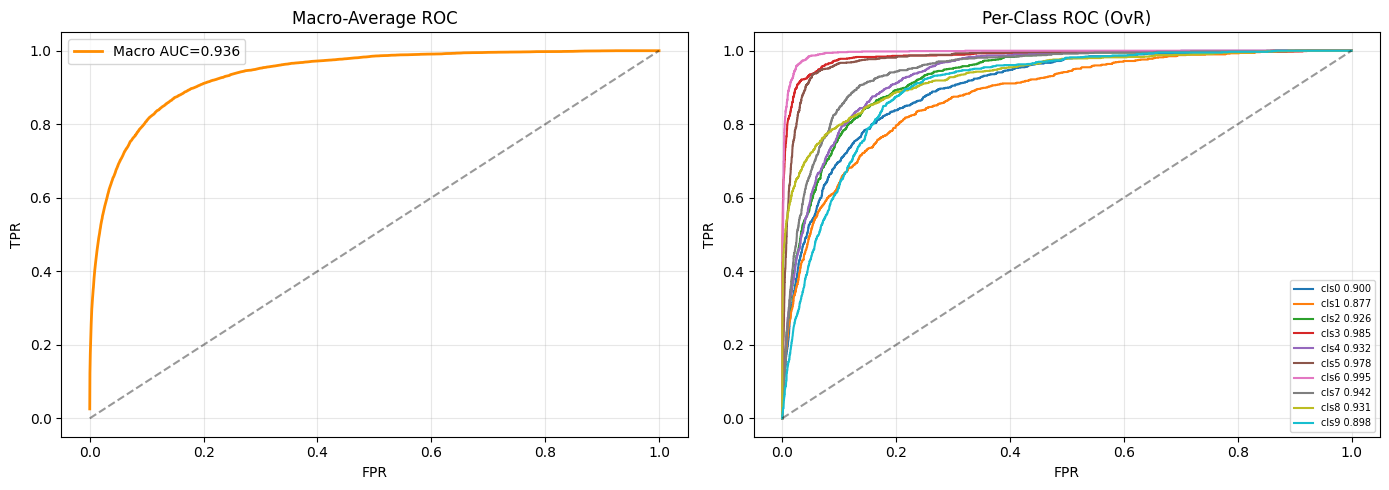

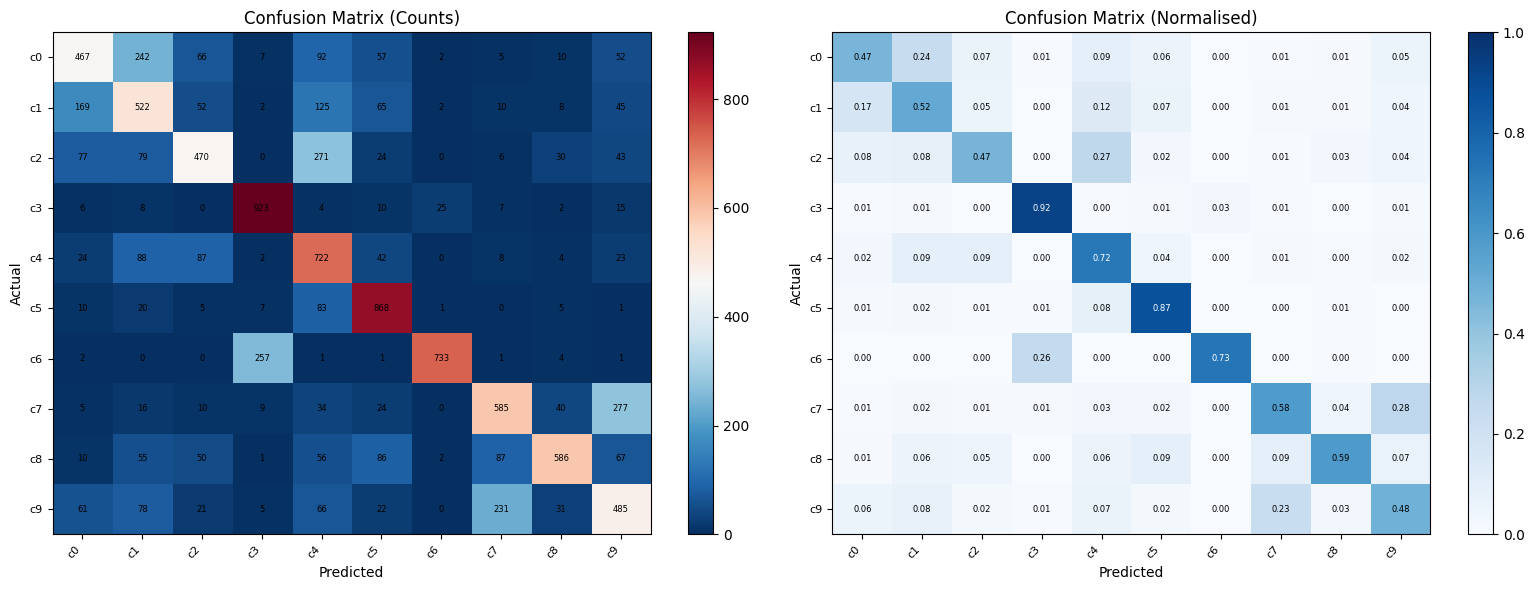

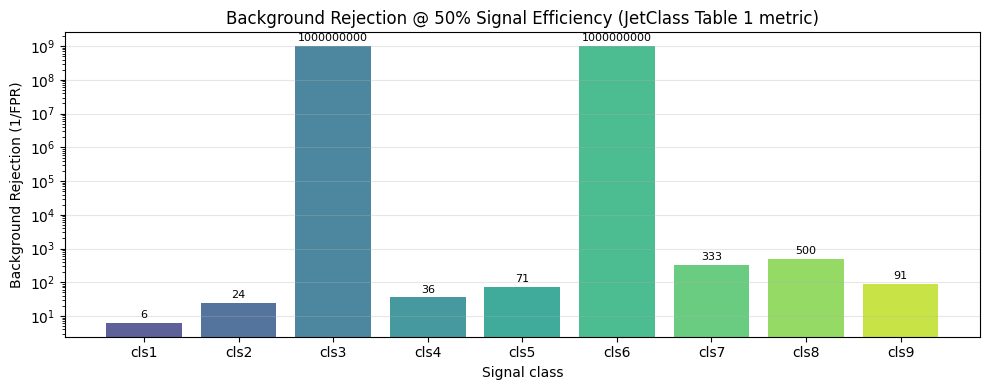


=== Per-class metrics (JetClass Table 1 format) ===
 class    AUC       Rej50%
     0 0.9002          NaN
     1 0.8769          6.2
     2 0.9255         24.4
     3 0.9852 1000000000.0
     4 0.9320         35.7
     5 0.9782         71.4
     6 0.9947 1000000000.0
     7 0.9424        333.3
     8 0.9311        500.0
     9 0.8979         90.9

              precision    recall  f1-score   support

           0       0.56      0.47      0.51      1000
           1       0.47      0.52      0.50      1000
           2       0.62      0.47      0.53      1000
           3       0.76      0.92      0.83      1000
           4       0.50      0.72      0.59      1000
           5       0.72      0.87      0.79      1000
           6       0.96      0.73      0.83      1000
           7       0.62      0.58      0.60      1000
           8       0.81      0.59      0.68      1000
           9       0.48      0.48      0.48      1000

    accuracy                           0.64     10000

In [9]:
# 5) End-to-end run (main experiment)

start = time.time()
# FIX 2: model built once in cell 10. Re-creating here wipes pretrained weights.

print('Running pretraining...')
run_pretrain(model, train_loader, val_loader, cfg)
print('[OK] Pretraining complete.')

print('Running finetuning...')
model.zero_grad(set_to_none=True)  # clear stale pretrain gradients
test_metrics = run_finetune(model, train_loader, val_loader, test_loader, cfg)

elapsed_min = (time.time() - start) / 60.0
print('\n=== Final Test Metrics ===')
print('Test loss   :', round(test_metrics['loss'], 5))
print('Test acc    :', round(test_metrics['acc'], 5))
print('Test mAUC   :', round(test_metrics['mauc'], 5))
print('Test Rej50  :', round(test_metrics['rej50'], 3))
print('Time (min)  :', round(elapsed_min, 2))

# ── Full GSoC diagnostic plots ───────────────────────────────────────────
if test_metrics.get('y_true') is not None and test_metrics.get('y_prob') is not None:
    _yt=test_metrics['y_true']; _yp=np.nan_to_num(test_metrics['y_prob'],nan=0.1)
    _C=_yp.shape[1]; _yoh=np.eye(_C)[_yt]; _ypred=_yp.argmax(1)

    # A) Macro-average + per-class ROC curves
    from sklearn.metrics import auc as _sk_auc
    _fpr_l,_tpr_l=[],[]
    for _i in range(_C):
        if _yoh[:,_i].sum()==0: continue
        _fp,_tp,_=roc_curve(_yoh[:,_i],_yp[:,_i]); _fpr_l.append(_fp); _tpr_l.append(_tp)
    _all_fpr=np.unique(np.concatenate(_fpr_l))
    _mean_tpr=sum(np.interp(_all_fpr,fp,tp) for fp,tp in zip(_fpr_l,_tpr_l))/len(_fpr_l)
    _mac=_sk_auc(_all_fpr,_mean_tpr)
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    axes[0].plot(_all_fpr,_mean_tpr,'darkorange',lw=2,label=f'Macro AUC={_mac:.3f}')
    axes[0].plot([0,1],[0,1],'k--',alpha=0.4); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('Macro-Average ROC'); axes[0].legend(); axes[0].grid(alpha=0.3)
    _cmap2=plt.cm.tab10
    for _i in range(min(_C,10)):
        if _yoh[:,_i].sum()==0: continue
        _fp,_tp,_=roc_curve(_yoh[:,_i],_yp[:,_i])
        axes[1].plot(_fp,_tp,color=_cmap2(_i/10),lw=1.5,label=f'cls{_i} {_sk_auc(_fp,_tp):.3f}')
    axes[1].plot([0,1],[0,1],'k--',alpha=0.4); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('Per-Class ROC (OvR)'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.savefig('roc_curves.png',dpi=150,bbox_inches='tight'); plt.show()

    # B) Confusion matrix — counts + row-normalised
    from sklearn.metrics import confusion_matrix as _cm_fn
    _cmr=_cm_fn(_yt,_ypred); _cmn=_cmr.astype(float)/_cmr.sum(1,keepdims=True).clip(1)
    fig,axes=plt.subplots(1,2,figsize=(16,6))
    for ax,data,title,cm_ in zip(axes,[_cmr,_cmn],['Counts','Normalised'],['RdBu_r','Blues']):
        im=ax.imshow(data,cmap=cm_,aspect='auto',vmin=0,vmax=(1 if title=='Normalised' else None))
        ax.set_xticks(range(_C)); ax.set_yticks(range(_C))
        ax.set_xticklabels([f'c{i}' for i in range(_C)],rotation=45,ha='right',fontsize=8)
        ax.set_yticklabels([f'c{i}' for i in range(_C)],fontsize=8)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(f'Confusion Matrix ({title})')
        for i in range(_C):
            for j in range(_C):
                v=data[i,j]; txt=f'{v:.0f}' if title=='Counts' else f'{v:.2f}'
                ax.text(j,i,txt,ha='center',va='center',fontsize=6,color='white' if (title=='Normalised' and v>0.6) else 'black')
        plt.colorbar(im,ax=ax)
    plt.tight_layout(); plt.savefig('confusion.png',dpi=150,bbox_inches='tight'); plt.show()

    # C) Background rejection @ 50% signal eff (JetClass Table 1)
    _rejs=[bkg_rej_at_eff(_yt,_yp,_i,0,0.5) for _i in range(1,_C)]
    fig,ax=plt.subplots(figsize=(10,4))
    _colors=plt.cm.viridis(np.linspace(0.2,0.9,len(_rejs)))
    _bars=ax.bar([f'cls{i}' for i in range(1,_C)],_rejs,color=_colors,alpha=0.85)
    ax.set_ylabel('Background Rejection (1/FPR)'); ax.set_xlabel('Signal class')
    ax.set_title('Background Rejection @ 50% Signal Efficiency (JetClass Table 1 metric)')
    ax.bar_label(_bars,fmt='%.0f',padding=2,fontsize=8)
    try: ax.set_yscale('log')
    except: pass
    ax.grid(axis='y',alpha=0.3)
    plt.tight_layout(); plt.savefig('bkg_rejection.png',dpi=150,bbox_inches='tight'); plt.show()

    # D) Per-class physics summary table (ParT paper Table 1 format)
    from sklearn.metrics import classification_report as _cr
    print('\n=== Per-class metrics (JetClass Table 1 format) ===')
    _pr=[{'class':_i,'AUC':(roc_auc_score(_yoh[:,_i],_yp[:,_i]) if _yoh[:,_i].sum()>0 else float('nan')),'Rej50%':bkg_rej_at_eff(_yt,_yp,_i,0,0.5)} for _i in range(_C)]
    print(pd.DataFrame(_pr).to_string(index=False,float_format=lambda x:f'{x:.1f}' if x>1 else f'{x:.4f}'))
    print()
    print(_cr(_yt,_ypred,zero_division=0))

# Save checkpoint
ckpt_dir = Path('./checkpoints')
ckpt_dir.mkdir(exist_ok=True)
torch.save({'model': model.state_dict(), 'cfg': cfg.__dict__, 'metrics': {k: v for k, v in test_metrics.items() if k not in ['y_true', 'y_prob']}}, ckpt_dir / 'final_notebook_best.pt')
print('Saved:', ckpt_dir / 'final_notebook_best.pt')

In [10]:
# 6) Optional ablation runner (for report)

from copy import deepcopy


def run_one_setting(
    base_cfg: Config,
    setting_name: str,
    use_jepa: bool,
    use_vicreg: bool,
    use_mass: bool,
    use_interaction: bool,
    use_token_gating: bool,
    use_physics_features: bool,
    seed: int,
    return_curve: bool = False,
):
    local = deepcopy(base_cfg)
    local.SEED = seed
    local.USE_JEPA_PRETRAIN = use_jepa
    local.USE_VICREG_ON_JEPA = use_vicreg
    local.USE_AUX_MASS = use_mass
    local.USE_INTERACTION_LEARNING = use_interaction
    local.USE_ATTN_TOKEN_GATING = use_token_gating
    local.USE_PHYSICS_FEATURES = use_physics_features

    # Keep requested lowercase ablation aliases synchronized.
    local.use_jepa = local.USE_JEPA_PRETRAIN
    local.use_interaction = local.USE_INTERACTION_LEARNING
    local.use_gating = local.USE_ATTN_TOKEN_GATING
    local.use_physics = local.USE_PHYSICS_FEATURES

    seed_everything(local.SEED)
    tr, va, te = build_loaders(local)

    m = HybridLorentzParT(local).to(device)
    if local.USE_TORCH_COMPILE and hasattr(torch, 'compile'):
        try:
            import torch._dynamo; torch._dynamo.config.suppress_errors = True
            m = torch.compile(m, mode='reduce-overhead')
        except Exception:
            pass

    t0 = time.time()
    run_pretrain(m, tr, va, local)
    tm = run_finetune(m, tr, va, te, local)
    dt = (time.time() - t0) / 60.0

    row = {
        'setting': setting_name,
        'seed': seed,
        'test_acc': tm['acc'],
        'test_mauc': tm['mauc'],
        'test_rej50': tm.get('rej50', float('nan')),
        'train_time_min': dt,
        'use_jepa': use_jepa,
        'use_vicreg': use_vicreg,
        'use_mass': use_mass,
        'use_interaction': use_interaction,
        'use_token_gating': use_token_gating,
        'use_physics_features': use_physics_features,
    }

    if return_curve:
        row['y_true'] = tm.get('y_true', None)
        row['y_prob'] = tm.get('y_prob', None)

    return row


def plot_roc_comparison_binary(result_rows, signal_cls=1, bkg_cls=0, title='ROC comparison'):
    plt.figure(figsize=(7, 5.5))
    has_curve = False
    for r in result_rows:
        y_true = r.get('y_true', None)
        y_prob = r.get('y_prob', None)
        if y_true is None or y_prob is None or y_prob.shape[1] <= max(signal_cls, bkg_cls):
            continue

        keep = np.isin(y_true, [signal_cls, bkg_cls])
        if keep.sum() < 4:
            continue

        y_bin = (y_true[keep] == signal_cls).astype(np.int32)
        score = y_prob[keep, signal_cls] / (y_prob[keep, signal_cls] + y_prob[keep, bkg_cls] + 1e-12)
        fpr, tpr, _ = roc_curve(y_bin, score)
        auc_val = roc_auc_score(y_bin, score)
        plt.plot(fpr, tpr, lw=2, label=f"{r['setting']} (AUC={auc_val:.4f})")
        has_curve = True

    if not has_curve:
        print('No valid ROC curves to plot.')
        return

    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


# ------------------------------------------------------------------
# Core comparison requested: Baseline, JEPA, Interaction, Gating, Full
# ------------------------------------------------------------------
CORE_COMPARE_SETTINGS = [
    ('Baseline', False, False, False, False),
    ('+JEPA', True, False, False, False),
    ('+Interaction', False, True, False, False),
    ('+Gating', False, False, True, False),
    ('Full model', True, True, True, True),
]

run_core_comparison = False
core_seed = 42

if run_core_comparison:
    core_rows = []
    # Explicit dictionary requested for concise model-to-model comparison.
    core_results = {}
    for name, uj, ui, ug, up in CORE_COMPARE_SETTINGS:
        print(f'\n=== Core comparison: {name} | seed={core_seed} ===')
        row = run_one_setting(
            cfg,
            setting_name=name,
            use_jepa=uj,
            use_vicreg=uj,        # VICReg only meaningful with JEPA branch on.
            use_mass=True,
            use_interaction=ui,
            use_token_gating=ug,
            use_physics_features=up,
            seed=core_seed,
            return_curve=True,
        )
        core_rows.append(row)
        core_results[name] = {
            'acc': float(row['test_acc']),
            'mauc': float(row['test_mauc']),
            'rej50': float(row['test_rej50']),
        }

    core_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_true', 'y_prob']} for r in core_rows])
    print('\nCore comparison table:')
    display(core_df.sort_values('test_mauc', ascending=False))
    print('\nCore comparison dictionary:')
    print(core_results)

    plot_roc_comparison_binary(core_rows, signal_cls=1, bkg_cls=0, title='Core model ROC: class 1 vs class 0')
else:
    print('Set `run_core_comparison=True` to run Baseline/+JEPA/+Interaction/+Gating/Full.')


# ------------------------------------------------------------------
# Extended multi-seed ablations (selection report quality)
# ------------------------------------------------------------------
AB_SETTINGS = [
    ('Scratch Hybrid', False, False, False, True, True, True),
    ('JEPA Hybrid', True, False, False, True, True, True),
    ('JEPA+VICReg Hybrid', True, True, False, True, True, True),
    ('JEPA+VICReg+Mass Hybrid', True, True, True, True, True, True),
    ('NoInteraction', True, True, True, False, True, True),
    ('NoTokenGating', True, True, True, True, False, True),
    ('NoPhysicsFeatures', True, True, True, True, True, False),
]

ABLATION_SEEDS = list(range(42, 47))  # 42,43,44,45,46

# Set run_ablation=True when you are ready (it is expensive)
run_ablation = False

if run_ablation:
    rows = []
    for name, uj, uv, um, ui, ug, up in AB_SETTINGS:
        for seed in ABLATION_SEEDS:
            print(f'\n=== {name} | seed={seed} ===')
            rows.append(run_one_setting(cfg, name, uj, uv, um, ui, ug, up, seed, return_curve=False))

    df = pd.DataFrame(rows)
    print('\nRaw results:')
    display(df)

    grp = df.groupby('setting')
    summary = grp.agg(
        test_acc_mean=('test_acc', 'mean'),
        test_acc_min=('test_acc', 'min'),
        test_acc_max=('test_acc', 'max'),
        test_mauc_mean=('test_mauc', 'mean'),
        test_mauc_min=('test_mauc', 'min'),
        test_mauc_max=('test_mauc', 'max'),
        test_rej50_mean=('test_rej50', 'mean'),
        test_rej50_min=('test_rej50', 'min'),
        test_rej50_max=('test_rej50', 'max'),
        train_time_min_mean=('train_time_min', 'mean'),
    )

    summary['test_acc_minus'] = summary['test_acc_mean'] - summary['test_acc_min']
    summary['test_acc_plus'] = summary['test_acc_max'] - summary['test_acc_mean']
    summary['test_mauc_minus'] = summary['test_mauc_mean'] - summary['test_mauc_min']
    summary['test_mauc_plus'] = summary['test_mauc_max'] - summary['test_mauc_mean']
    summary['test_rej50_minus'] = summary['test_rej50_mean'] - summary['test_rej50_min']
    summary['test_rej50_plus'] = summary['test_rej50_max'] - summary['test_rej50_mean']

    print('\nSummary (mean with min/max interval):')
    display(summary)
else:
    print('Set `run_ablation=True` to execute multi-seed ablations (42-46).')

Set `run_core_comparison=True` to run Baseline/+JEPA/+Interaction/+Gating/Full.
Set `run_ablation=True` to execute multi-seed ablations (42-46).


## Usage Notes

- Run cells in order.
- This notebook is aligned to CMS Specific Task 2a:
  - hybrid L-GATr + ParT model,
  - JEPA-style pretraining improvement,
  - optional mass regression,
  - strict 100,000-event budget with 80/10/10 split,
  - ablation reporting for accuracy/AUC/background rejection.
- `STRICT_DATASET_ONLY=True` is enabled by default; if data are missing, the notebook raises an error instead of silently using synthetic data.
- Last-year reproducibility protocol is integrated: mask-mode discipline + 5-seed ablations (42-46).